# Advanced training module: Data selection to reduce analysis runtime.

## Theme: Analysis

The malariagen_data python package is a constantly growing resource with thousands of *Anopheles* whole genomes contained within hundreds? of sample_sets. With this rich data resource at your fingertips, it may be tempting to include all relevant data that is out of embargo in your data analysis. However, such a large amount of data can be challenging to deal with and it is often not possible to include all of it. For example, analysis used to investigate population structure including PCA, NJT and F<sub>ST</sub> analysis can take a large amount of computational power to run. Often this is more than alloted to a single user by google colab and you may find that your runtime crashes with an error stating that you have run out of memory. As a result there is often a need to restrict the data you use so that the number of samples is reduced, but still adequate to effectively answer your scientific question. In this training module, we will walk through an example where we have a large amount of data avaliable for our scientific investigation and need to reduce this to lower the computational resources required.

## Learning Objectives

At the end of this module you will be able to:

- Select the most appropriate data to use in analysis.
- Reduce computational runtime.


## Population structure of *An. gambiae* in West Africa

We are going to investigate the population structure of *An. gambiae* across the West African region, not including the Far West countries of The Gambia, Guinea-Bissau and Guinea. To do this, we must investigate the data avaliable for analysis for *An. gambiae* from our countries of interest. First we can load malariagen_data and get all the sample metadata for *An. gambiae* out of embargo. We can use data out of embargo with no restrictions.

Import packages for easy visualisation of the data.

In [1]:
%pip install -qq ipyleaflet
import ipyleaflet

Note: you may need to restart the kernel to use updated packages.


In [2]:
#import os
#import plotly.express as px
#import plotly.io as pio
#pio.renderers.default = "notebook+colab"

First let's install and import the malariagen_data package.

In [3]:
!pip install malariagen_data


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import malariagen_data

In [5]:
ag3=malariagen_data.Ag3()

In [6]:
df_samples=ag3.sample_metadata(sample_query='taxon == "gambiae" and unrestricted_use == True')

Let's see which countries are represented in the data.

In [7]:
df_samples.country.unique()

array(['Mali', 'Uganda', 'Ghana', 'Burkina Faso', 'Gabon', 'Benin',
       "Cote d'Ivoire", 'Tanzania', 'Togo',
       'Democratic Republic of the Congo', 'Cameroon', 'Gambia, The',
       'Zambia', 'Kenya', 'Nigeria', 'Central African Republic',
       'Mayotte', 'Guinea', 'Equatorial Guinea', 'Guinea-Bissau',
       'Mozambique', 'Comoros, The Union of the', 'Madagascar'],
      dtype=object)

Now we know which West African countries are represented by the data, we can query the sample metadata to extract the *An. gambiae* data and to generate a map to visualise this.

In [8]:
pivot_gambiae_samples = (
    df_samples.query('country in ["Mali","Ghana","Burkina Faso","Benin", "Cote d\'Ivoire","Togo"]')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "admin2_name", "longitude","latitude","year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_gambiae_samples

taxon                                                                                       gambiae
country sample_set                    admin1_name     admin2_name  longitude latitude year         
Benin   1237-VO-BJ-DJOGBENOU-VMF00067 Donga           Djougou       1.667    9.700    2017       64
        1237-VO-BJ-DJOGBENOU-VMF00212 Mono            Athieme       1.754    6.502    2018        2
                                                                    1.760    6.495    2018        3
                                                                    1.768    6.518    2018        2
                                                      Come          1.898    6.379    2018        1
...                                                                                             ...
Mali    AG1000G-ML-B                  Segou           Baroueli     -6.130    13.200   2004        1
        campos-2021                   Koulikouro      Kangaba      -8.280    11.700   2006        3
                                                      Kati         -7.980    12.800   2006        3
        fontaine-2015-rebuild         Koulikouro      Kangaba      -8.450    11.880   2004       10
Togo    1253-VO-TG-DJOGBENOU-VMF00052 Maritime Region Lome Commune  1.314    6.161    2017      179

[125 rows x 1 columns]

In [9]:
# create a map
m = ipyleaflet.Map(
    basemap=ipyleaflet.basemaps.OpenStreetMap.Mapnik,
    center=[12, -3],
    zoom=5,
)

# add markers for sampling locations
for row in pivot_gambiae_samples.reset_index().itertuples():
    title = (
        f"{row.country},{row.admin1_name}, {row.admin2_name}, {row.year} \n"
        f"{row.gambiae} gambiae"
    )
    marker = ipyleaflet.Marker(
        location=(row.latitude, row.longitude),
        draggable=False,
        title=title,
    )
    m.add_layer(marker)

# add a scale bar
m.add_control(ipyleaflet.ScaleControl(position="bottomleft"))

# display the map
m

Map(center=[12, -3], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

Looking at the map you can see that there are a number of data sets that seem to fall in the same location, for example in Ghana and Mali. This suggests we have duplicate data for particular locations. Given we are looking at large-scale patterns of population structure, we are not particularly interested in fine-grained local structure. Therefore, we may be able to reduce the data we need.

Now we have an overview, we can look at the sample sets avaliable for each country in turn to see whether we can be selective in the data we input into analysis.

In [10]:
#We will set the maximum number of rows displayed by pandas to be larger, so we can easily see all rows in the sample metadata summary.
#pd.set_option('display.max_rows', 50)

The first country we will investigate is Benin. We can query the sample metadata table and generate a pivot table to summarise the data.

In [11]:
pivot_ben_samples = (
    df_samples
    .query('country == "Benin"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_ben_samples

taxon                                                   gambiae
country sample_set                    admin1_name year         
Benin   1237-VO-BJ-DJOGBENOU-VMF00067 Donga       2017       64
        1237-VO-BJ-DJOGBENOU-VMF00212 Mono        2018       21

There are two sample sets here representing two different administrative districts in Benin. Looking at the map above these regions are fairly distant. Therefore, we may wish to include all the data if there is geographical population structure present between *An. gambiae* across the country. However, knowing this will require its own seperate investigation into population structure, such as a PCA analysis. Since this is not a comprehensive analysis but a quick investigation, we can take a couple of shortcuts to speed up analysis.

First, we usually only require the first three principal components for an investigation of populations structure, because these components are usually sufficient to explain the variance in the data. The more components we generate, the longer the run time to calculate these. Therefore, we can **specifiy the number of components** we would like to generated using the parameter n_components and set this is to be three.

Secondly, since we need only a rough idea of whether there is restricted gene flow between the two regions in Benin, we do not need to demonstrate our findings with a large number of samples. Therefore, we can downsample the data so that we have a small number of individuals representating each administrative region. We can **downsample by setting the cohort_size** to the number of samples we would like to use. This only has to be large enough so that a number of individuals from each administative region are selected for. Again, the more individuals you have, the longer the runtime. In this example, I have chosen just 50 individuals.

Thirdly, we can **reduce the number of SNPs** that are selected for analysis. Usually, it is recomended to use 100,000 SNPs from across the 3L chromosome region. However, since our analysis does not have to be vigorous, but we would also like it to accurately represent population strucure, we can make do with 50,000 SNPs.

After setting our parameters, we can run the PCA analysis using the Benin sample sets 1237-VO-BJ-DJOGBENOU-VMF00067 and 1237-VO-BJ-DJOGBENOU-VMF00212.

In [12]:
region = "3L:15,000,000-41,000,000"
n_components = 3
cohort_size=50
n_snps = 50_000

In [13]:
ben_pca_df, ben_evr_df = ag3.pca(region=region, n_snps=n_snps, sample_sets=["1237-VO-BJ-DJOGBENOU-VMF00067","1237-VO-BJ-DJOGBENOU-VMF00212"], sample_query="taxon == 'gambiae' and unrestricted_use == True", site_mask='gamb_colu', cohort_size=cohort_size, n_components=n_components)

Compute SNP allele counts:   0%|          | 0/3870 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/4042 [00:00<?, ?it/s]

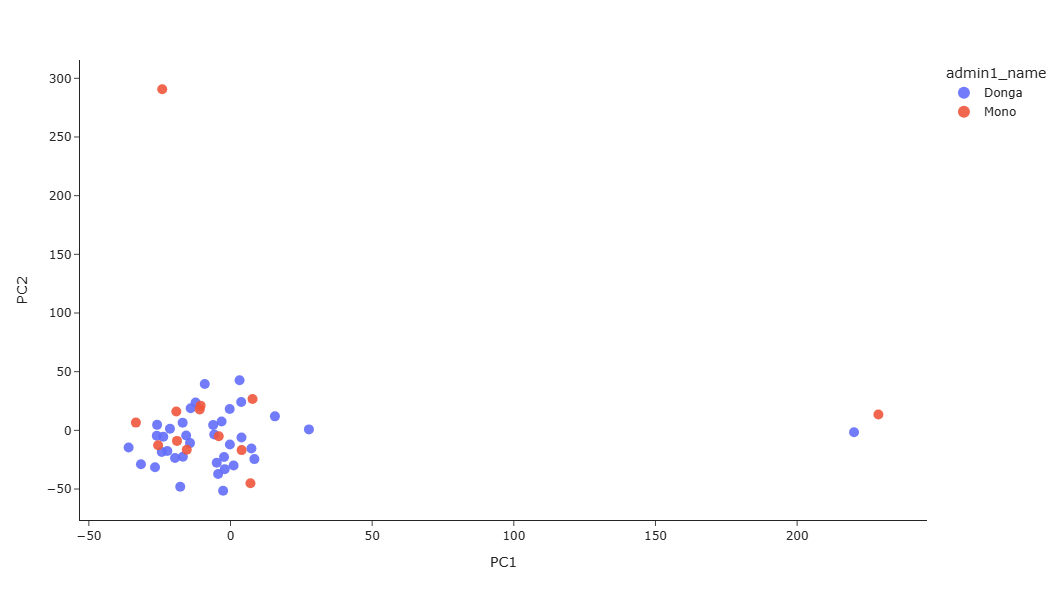

In [14]:
ag3.plot_pca_coords(
    ben_pca_df,
    color="admin1_name",
)

Looking at the PCA, *An. gambiae* from the administrative regions of Donga and Mono in Benin fall within the same PCA cluster, suggesting there is no restricted gene flow between them. Therefore, just one of the sample sets would be sufficient to represent Benin. When making such a decision you could **consider the number of samples in each sample set and the time of sampling**. Here, 1237-VO-BJ-DJOGBENOU-VMF00212 is the most recent from 2019 and includes 21 samples, while 1237-VO-BJ-DJOGBENOU-VMF00067 is from 2017 and represented by 64 individuals. Both sample sets were sampled at a time that is comparable to much of the data we are looking to include, but including 1237-VO-BJ-DJOGBENOU-VMF00212 only is more likely reduce our runtime while still being representative of the data we have from Benin.

Next let's consider Burkina Faso.

In [15]:
pivot_bf_samples = (
    df_samples
    .query('country == "Burkina Faso"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_bf_samples

taxon                                                             gambiae
country      sample_set                       admin1_name   year         
Burkina Faso 1191-VO-MULTI-OLOUGHLIN-VMF00106 Hauts-Bassins 2014       28
             1191-VO-MULTI-OLOUGHLIN-VMF00140 Hauts-Bassins 2014       94
                                                            2015      140
                                                            2016      104
                                                            2017       37
             1314-VO-BF-KIENTEGA-KIMA-BF-2104 Hauts-Bassins 2017       15
                                                            2018       18
                                                            2019       16
             AG1000G-BF-A                     Hauts-Bassins 2012       99
             AG1000G-BF-B                     Hauts-Bassins 2014       46
             AG1000G-BF-C                     Centre-Sud    2004       13
             fontaine-2015-rebuild            Hauts-Bassins 2012        4

Looking at the pivot table, several datasets are present but almost all represent the same administrative district of Hauts-Bassins. Some of the data are also comparatively old. For example, sample sets 1191-VO-MULTI-OLOUGHLIN-VMF00106, AG1000G-BF-A, AG1000G-BF-B and fontaine-2015-rebuild are from 2014 or before. The data we previously selected for Benin was from 2019, which was similar to a number of other West African datasets. The sample set 1314-VO-BF-KIENTEGA-KIMA-BF-2104 has data from this time, and also has less samples than the other more recent sample set 1191-VO-MULTI-OLOUGHLIN-VMF00140.

Although a sample set AG1000G-BF-C represents a different administative district, Centre-Sud, this data is from 2004. Therefore, if we observed restricted gene flow between this region and Hauts-Bassins, it would be difficult to know whether this was true population structure or simply the result of genetic differences that have accumulated over time due to genetic drift. We can therefore, also discount the sample set AG1000G-BF-C.

Overall, due to it being a more recent sample set of fewer samples representing the region of Hauts-Bassin, 1314-VO-BF-KIENTEGA-KIMA-BF-2104 is a good choice to represent *An. gambiae* from Burkina Faso.

The next country to investigate is Cote d'Ivoire.

In [16]:
pivot_ci_samples = (
    df_samples
    .query('country == "Cote d\'Ivoire"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_ci_samples

taxon                                                              gambiae
country       sample_set                   admin1_name       year         
Cote d'Ivoire 1245-VO-CI-CONSTANT-VMF00054 Comoe             2017       37
              1279-VO-CI-KOFFI-VMF00173    Comoe             2020        6
                                           Montagnes         2020        8
                                           Savanes           2020       66
                                           Vallée du Bandama 2020       12

For Cote d"Ivoire, we have the same administrative district of Comoe represented by two sample sets. The sample set 1279-VO-CI-KOFFI-VMF00173 have several other locations. However, it is also from a more recent time point than the sample sets we have decided to include so far. Again, we may wish to investigate population structure in the country, to determine whether there is a need to include these other populations to represent *An. gambiae* in Cote d'Ivoire. We can use the same tricks as previously to reduce the runtime and produce a rough PCA analysis.

In [17]:
cdi_pca_df, cdi_evr_df = ag3.pca(region=region, n_snps=n_snps, sample_sets=["1245-VO-CI-CONSTANT-VMF00054","1279-VO-CI-KOFFI-VMF00173"], sample_query="taxon == 'gambiae' and unrestricted_use == True", site_mask='gamb_colu', cohort_size=cohort_size, n_components=n_components)

Compute SNP allele counts:   0%|          | 0/3956 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/4128 [00:00<?, ?it/s]

In [18]:
ag3.plot_pca_coords(
    cdi_pca_df,
    color="admin1_name",
)

We find that *An. gambiae* from Comoe, including samples from both the 2017 and 2020 sample sets, disperse from the main cluster of *An. gambiae* originating from Vallee du Bandama, Savanes and Montages. Since the individuals from Comoe do not form a disinct cluster, the population structure we observe could result from a different demographic history rather than restricted gene flow in Cote D'Ivoire. However, it would be prudent to include all locations in our analysis and therefore choose the sample set 1279-VO-CI-KOFFI-VMF00173.

Next we will consider the data from Ghana.

In [19]:
pivot_gambiae_samples = (
    df_samples
    .query('country == "Ghana"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_gambiae_samples

taxon                                                               gambiae
country sample_set                       admin1_name          year         
Ghana   1190-VO-GH-AMENGA-ETEGO-VMF00013 Upper East Region    2016       26
        1190-VO-GH-AMENGA-ETEGO-VMF00028 Upper East Region    2017        1
        1190-VO-GH-AMENGA-ETEGO-VMF00029 Upper East Region    2017       57
        1190-VO-GH-AMENGA-ETEGO-VMF00046 Upper East Region    2017       16
        1190-VO-GH-AMENGA-ETEGO-VMF00047 Upper East Region    2017        2
        1190-VO-GH-AMENGA-ETEGO-VMF00088 Upper East Region    2018        6
        1190-VO-GH-AMENGA-ETEGO-VMF00102 Upper East Region    2018        3
        1244-VO-GH-YAWSON-VMF00051       Ashanti Region       2017      198
                                         Greater Accra Region 2017      200
        1244-VO-GH-YAWSON-VMF00149       Ashanti Region       2018       63
        AG1000G-GH                       Eastern Region       2012       23
                                         Greater Accra Region 2012       13

When looking at the sample sets avaliable from Ghana, we can see that there are numerous sample sets for the administrative region of the Upper East. Comparing these sample sets, 1190-VO-GH-AMENGA-ETEGO-VMF00013 was sampled in 2016 which is slightly older than the other sample sets from West Africa we are including in analysis, ranging from 2017 to 2020. All other sample sets fall within this timeframe and are therefore the most comparable. Of these, 1190-VO-GH-AMENGA-ETEGO-VMF00088 and 1190-VO-GH-AMENGA-ETEGO-VMF00102 are the most recent being sampled from 2019 but includes just 6 or 3 samples and can therefore be excluded. From 2017, 1190-VO-GH-AMENGA-ETEGO-VMF00028 and 1190-VO-GH-AMENGA-ETEGO-VMF00047	have just 1 or 2 samples and so we can exclude these too. 1190-VO-GH-AMENGA-ETEGO-VMF00029	and
1190-VO-GH-AMENGA-ETEGO-VMF00046 are both from 2017 and can be considered for  inclusion, but we do not require both sample sets. In this case, to reduce the runtime as much as possible, we can include 1190-VO-GH-AMENGA-ETEGO-VMF00046 which has 16 samples compared to the 57 in the other sample set.

The remaining sample sets 1244-VO-GH-YAWSON-VMF00051, 1244-VO-GH-YAWSON-VMF00149 and AG1000G-GH include other administrative districts in Ghana. These are southern regions in Ghana that are geographically distant to the Upper East while restricted gene flow has been observed between the North and South of Ghana in other *Anopheles* species (Amoake et al. 2026). Therefore, we could consider including both the Upper East and southern districts in our analysis. We can also perform our own investigation into the remaining sample sets to determine which is the best representation of the South. Again, we can perform a PCA.

In [20]:
gh_pca_df, gh_evr_df = ag3.pca(region=region, n_snps=n_snps, sample_sets=["1244-VO-GH-YAWSON-VMF00051","1244-VO-GH-YAWSON-VMF00149","AG1000G-GH"], sample_query="taxon == 'gambiae' and unrestricted_use == True", site_mask='gamb_colu', cohort_size=cohort_size, n_components=n_components)

Compute SNP allele counts:   0%|          | 0/9374 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/9546 [00:00<?, ?it/s]

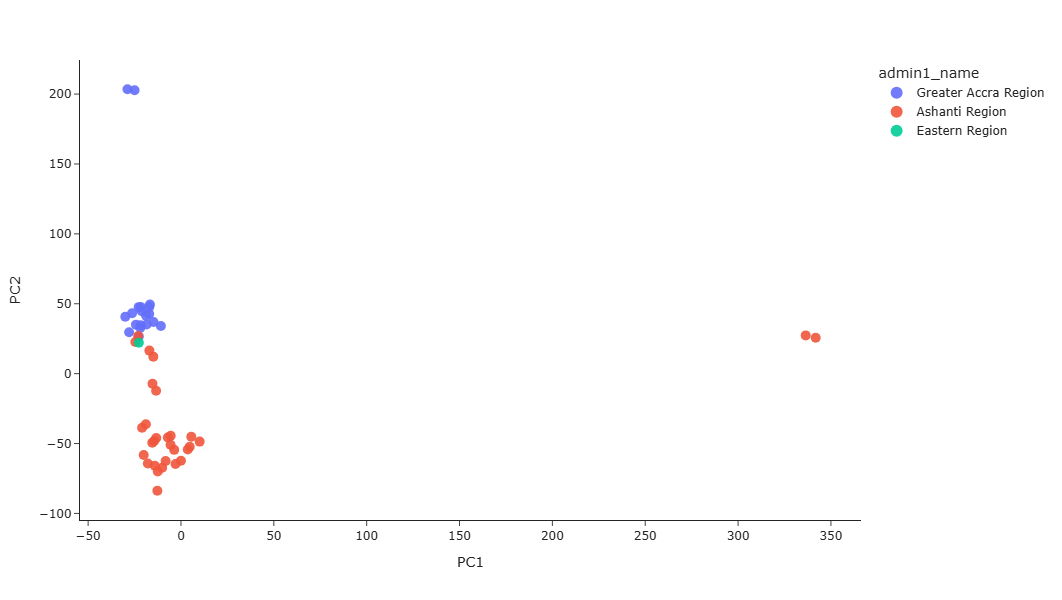

In [21]:
ag3.plot_pca_coords(
    gh_pca_df,
    color="admin1_name",
)

In the PCA, *An. gambiae* from the Eastern region falls together with both Greater Accra and some individuals from Ashanti, while many individuals from Ashanti sit somewhat apart. Therefore, it seems that the dataset 1244-VO-GH-YAWSON-VMF00051, which has both Ashanti and Greater Accra would be sufficient to explain the pattern of population structure in Ghana.

Mali is the next country to investigate.

In [22]:
pivot_gambiae_samples = (
    df_samples
    .query('country == "Mali"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_gambiae_samples

taxon                                                      gambiae
country sample_set                       admin1_name year         
Mali    1177-VO-ML-LEHMANN-VMF00004      Koulikouro  2012        5
                                                     2014       16
                                                     2015       23
        1177-VO-ML-LEHMANN-VMF00015      Koulikouro  2014        1
        1191-VO-MULTI-OLOUGHLIN-VMF00106 Koulikouro  2014       65
                                                     2015       69
        AG1000G-GN-B                     Sikasso     2012       65
        AG1000G-ML-A                     Koulikouro  2014       33
        AG1000G-ML-B                     Koulikouro  2004       32
                                         Segou       2004        1
        campos-2021                      Koulikouro  2006        6
        fontaine-2015-rebuild            Koulikouro  2004       10

Once again we have multiple datasets representing the same administrative district in Mali. Furthermore, looking at the map all administrative districts including Koulikouro, Sikasso and Segou are geographically proximate and found within the same southern region of the country. Many of the datasets including AG1000G-ML-B, campos-2021 and fontaine-2015-rebuild are comparatively old from 2004, and we can drop these datasets. The other datasets span a similar  timeframe from 2012 to 2015. Since the other data we are analysing are from 2017 upwards it makes sense to choose the more recent data for comparison. Both datasets 1177-VO-ML-LEHMANN-VMF00004 and 1191-VO-MULTI-OLOUGHLIN-VMF00106 have the most recent data from 2015 but 1177-VO-ML-LEHMANN-VMF00004 has less data and so may be the best choice to reduce runtime.

Finally, there is only one dataset for Togo and so we should also include this in analysis.

In [23]:
pivot_gambiae_samples = (
    df_samples
    .query('country == "Togo"')
    .pivot_table(
        index=["country", "sample_set", "admin1_name", "year"],
        columns=["taxon"],
        values="sample_id",
        aggfunc="count",
        fill_value=0
    )
)
pivot_gambiae_samples

,,,taxon,gambiae
country,sample_set,admin1_name,year,
Togo,1253-VO-TG-DJOGBENOU-VMF00052,Maritime Region,2017,179


Now we have decided on all the datasets we will include we can run the full PCA this time specifying 100,000 SNPs and removing the cohort size parameter to include all individuals. Now we have reduced the sample sets, the PCA will only take around 13 minutes to run.

In [24]:
wa_pca_df, wa_evr_df = ag3.pca(region=region, n_snps=100_000, sample_sets=["1237-VO-BJ-DJOGBENOU-VMF00212", "1314-VO-BF-KIENTEGA-KIMA-BF-2104", "1279-VO-CI-KOFFI-VMF00173", "1190-VO-GH-AMENGA-ETEGO-VMF00046", "1244-VO-GH-YAWSON-VMF00051", "1177-VO-ML-LEHMANN-VMF00004", "1253-VO-TG-DJOGBENOU-VMF00052"], sample_query="taxon == 'gambiae'", site_mask='gamb_colu', n_components=n_components)

Compute SNP allele counts:   0%|          | 0/18232 [00:00<?, ?it/s]

Compute biallelic diplotypes:   0%|          | 0/19264 [00:00<?, ?it/s]

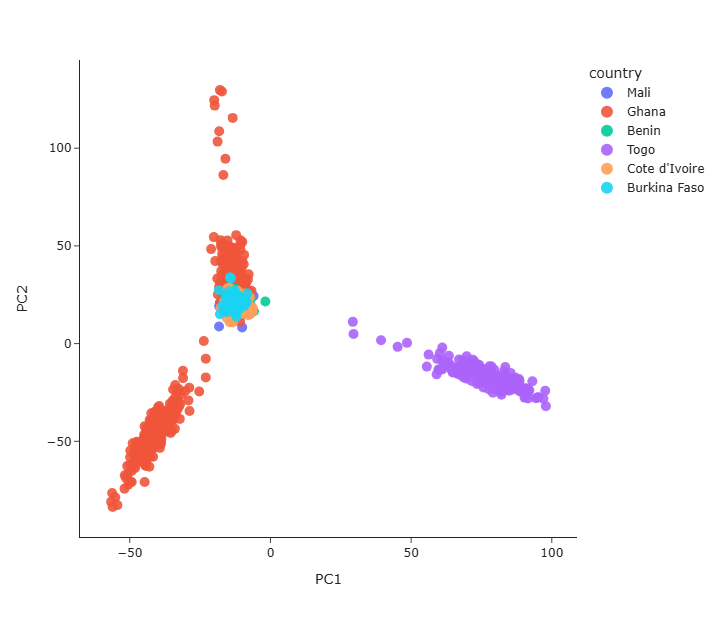

In [25]:
ag3.plot_pca_coords(
    wa_pca_df,
    color="country",
)

In this PCA, we can now see some interesting geographical population structure in West Africa revealed by our data selection ready. We can see at least three clusters representing Togo, the Ashanti region of Ghana and all other populations from Mali, Burkina, Ghana, Benin, Cote d'Ivoire and Burkina Faso, ready for further exploration.

## Well done!

In this module we have explored how to select sample sets so that we can run computationally intensive analysis without reaching the memory limit. Reducing the data allowed us to explore the poplation structure of *An. gambiae* using a large number of sample sets across all our selected West African countries without compromising our scientific aims.